In [19]:
# notebook for monitoring the pipeline
import os
from db_queries import *

client = MongoClient(os.getenv("MONGO"))
db = client["zeolite_tdm"]
papers = db["papers"]
paras = db["paragraphs"]

/var/folders/8_/h3p7rj817jq__tbf5rl73rq80000gn/T/ipykernel_39276/121877660.py:5: UserWarning: You appear to be connected to a CosmosDB cluster. For more information regarding feature compatibility and support please visit https://www.mongodb.com/supportability/cosmosdb
  client = MongoClient(os.getenv("MONGO"))


In [20]:
report_collection_counts(db)

DOC COUNTS
  - papers: 91 documents
  - paragraphs: 2137 documents
  - tables: 195 documents


In [21]:
status_report(db)

STATUS REPORT
- awaiting paragraph classification: 52
- rejected: 27
- awaiting process identification: 7
- processing: 5


REJECTION REPORT
- accepted: 64
- no tables: 13
- review article: 6
- missing keywords: 5
- no BET table: 3


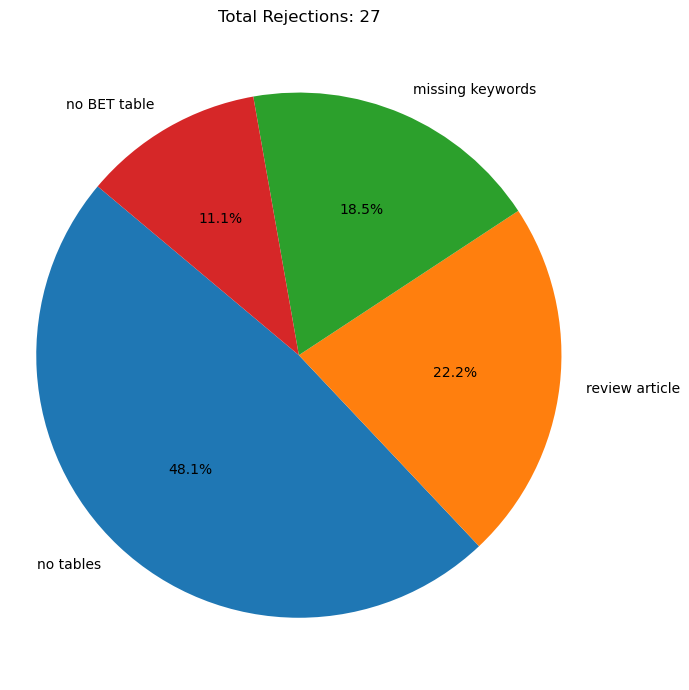

In [22]:
rejection_report(db)

In [24]:
paper_id = papers.find_one({"status": "awaiting process identification"})["_id"]
samples = db["samples"]
print("Sample count:", samples.count_documents({"paper_id": paper_id}))

Sample count: 6
